# Validation des contributions du chapitre 4 avec QUASAR

Notebook reproductible qui **pilote QUASAR** (déjà développé) pour valider
empiriquement les bornes du chapitre 4 : justesse, finesse, scénarios,
scalabilité. Brief : `PLAN_EXPERIMENTAL_validation_chap4.md`.

> **Règle méthodologique absolue.** Aucun résultat n'est simulé ni inventé.
> Chaque chiffre provient d'un appel réel à la CLI `quasar`. Quand une capacité
> nécessaire n'existe pas (commande/option absente, oracle externe non installé,
> modèle non disponible), la cellule est **marquée bloquée** (`⚠️ BLOQUÉ` /
> `SKIPPED`) et une **fiche de proposition** est consignée en **Section 7** —
> jamais contournée par un faux résultat.

**Vérité terrain disponible selon l'environnement :**
- *Oracle exact interne de QUASAR* (CTMC / MDD / BFS du cône via `analyze
  compare`) — toujours disponible, sert d'assertion de justesse H1.
- *Oracles externes* MaBoSS (empirique) et Storm (exact) — utilisés s'ils sont
  installés ; sinon les cellules correspondantes sont `SKIPPED`.

## Section 0 — Environnement & reproductibilité

In [1]:
import os
# Évite un deadlock du runtime de threads MKL sur `numpy.dot` (utilisé par les
# transforms matplotlib) : doit être positionné AVANT l'import de numpy.
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")

import sys, json, time, shutil, subprocess, platform, re, textwrap
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def find_repo(start):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / "bench" / "models").is_dir():
            return q
    return p

REPO = find_repo(os.environ.get("QUASAR_REPO", Path.cwd()))

def find_jar():
    env = os.environ.get("QUASAR_JAR")
    if env and Path(env).is_file():
        return Path(env)
    hits = sorted(REPO.glob("cli/target/scala-*/quasar.jar"))
    if hits:
        return hits[0]
    raise FileNotFoundError(
        "quasar.jar introuvable. Construire avec `sbt cli/assembly` "
        "ou définir la variable d'environnement QUASAR_JAR."
    )

JAR        = find_jar()
MODELS_DIR = REPO / "bench" / "models"
EXP        = REPO / "experiments"
FIG        = EXP / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Paramètres de reproductibilité
SEED      = 42          # graine (oracles stochastiques type MaBoSS)
N_SAMPLES = 100_000     # trajectoires MaBoSS (si présent)
MAX_TIME  = 100.0       # horizon temporel MaBoSS
TIMEOUT   = 180         # s par commande quasar
EPS       = 1e-9        # tolérance des assertions de justesse

print("REPO :", REPO)
print("JAR  :", JAR, f"({JAR.stat().st_size // 1024} Kio)")
print("SEED :", SEED, "| N_SAMPLES :", N_SAMPLES, "| TIMEOUT :", TIMEOUT, "s")

REPO : /home/lfippo/Dev/quasar
JAR  : /home/lfippo/Dev/quasar/cli/target/scala-3.3.4/quasar.jar (38477 Kio)
SEED : 42 | N_SAMPLES : 100000 | TIMEOUT : 180 s


**Pilotage de QUASAR.** Conformément au plan (§0, §6.1), tout passe par la CLI
avec `--json` en sous-processus — contrat stable, aucun état caché. Le SDK
`pyquasar` existe désormais (façade `io.quasar.py.Quasar`) mais on conserve le
pilotage CLI par défaut pour la reproductibilité (voir le choix documenté en
Section 7).

> *Note reproductibilité.* L'option globale `--cache-dir` du plan n'est pas
> câblée dans la CLI ; on mémoïse donc les appels **au niveau notebook**
> (dictionnaire `_CACHE`). Cellules idempotentes : ré-exécuter ne relance pas un
> appel déjà vu. Fiche correspondante en Section 7.

In [2]:
_CACHE = {}

def run_quasar(args, timeout=TIMEOUT, want_json=True, use_cache=True, cwd=None):
    """Pilote `quasar` en sous-processus et renvoie un dict normalisé.

    Champs : _ok (bool), _rc, _elapsed (s), _raw (texte), data (JSON ou None),
    _unavailable (binaire oracle absent), _timeout.
    """
    a = list(args)
    if want_json and "--json" not in a:
        a = a + ["--json"]
    key = (tuple(a), str(cwd))
    if use_cache and key in _CACHE:
        return _CACHE[key]
    cmd = ["java", "-jar", str(JAR), *a]
    t0 = time.perf_counter()
    try:
        p = subprocess.run(cmd, capture_output=True, text=True,
                           timeout=timeout, cwd=cwd)
        dt = time.perf_counter() - t0
        rc, out, err = p.returncode, p.stdout.strip(), p.stderr.strip()
    except subprocess.TimeoutExpired:
        res = {"_ok": False, "_rc": 124, "_elapsed": float(timeout),
               "_timeout": True, "_raw": "", "data": None, "_args": a}
        if use_cache:
            _CACHE[key] = res
        return res
    res = {"_rc": rc, "_elapsed": dt, "_args": a, "_raw": out or err,
           "_timeout": False, "_unavailable": False, "data": None}
    blob = (out + "\n" + err).lower()
    if rc == 2 and "introuvable" in blob:
        res["_ok"] = False
        res["_unavailable"] = True
    else:
        res["_ok"] = (rc == 0)
        try:
            res["data"] = json.loads(out)
        except Exception:
            res["data"] = None
    if use_cache:
        _CACHE[key] = res
    return res

# fumée : version de QUASAR
_v = run_quasar(["-V"], want_json=False)
print(_v["_raw"])

quasar 0.1.0-SNAPSHOT
adaptateurs externes : NuSMV/Storm/MaBoSS (détection à l'exécution)


In [3]:
def _sh(cmd):
    try:
        return subprocess.run(cmd, capture_output=True, text=True, timeout=30)
    except Exception:
        return None

rows = []
_q = run_quasar(["-V"], want_json=False)
rows.append(("QUASAR", _q["_raw"].splitlines()[0] if _q["_raw"] else "?"))
_j = _sh(["java", "-version"])
rows.append(("Java", _j.stderr.splitlines()[0] if _j and _j.stderr else "?"))
rows.append(("Python", sys.version.split()[0]))
rows.append(("pandas", pd.__version__))
rows.append(("OS", platform.platform()))
for b in ["MaBoSS", "MaBoSS_2.0", "maboss", "storm", "NuSMV"]:
    rows.append((b, shutil.which(b) or "absent"))
ENV = pd.DataFrame(rows, columns=["composant", "version / chemin"])
ENV

,composant,version / chemin
0,QUASAR,quasar 0.1.0-SNAPSHOT
1,Java,"openjdk version ""21.0.11"" 2026-04-21 LTS"
2,Python,3.11.5
3,pandas,2.0.3
4,OS,Linux-6.8.0-124-generic-x86_64-with-glibc2.35
5,MaBoSS,absent
6,MaBoSS_2.0,absent
7,maboss,absent
8,storm,absent
9,NuSMV,absent


In [4]:
# Disponibilité des oracles externes (détection par le PATH).
ORACLES = {
    "maboss": any(shutil.which(x) for x in ["MaBoSS", "MaBoSS_2.0", "maboss"]),
    "storm":  shutil.which("storm") is not None,
    "nusmv":  shutil.which("NuSMV") is not None,
}
print("Oracles externes détectés :", ORACLES)
if not (ORACLES["maboss"] or ORACLES["storm"]):
    print(textwrap.dedent('''
    ⚠️ Aucun oracle externe (MaBoSS/Storm) dans cet environnement.
       → H1/H5 (volet externe) et H2/H4 seront marqués SKIPPED — JAMAIS inventés.
       → Vérité terrain utilisée ici : oracle EXACT INTERNE de QUASAR
         (CTMC/MDD via `analyze probability --symbolic` et BFS du cône via
         `analyze compare`, qui pose `sound = (binf ≤ exact)`).
    '''))

Oracles externes détectés : {'maboss': False, 'storm': False, 'nusmv': False}

⚠️ Aucun oracle externe (MaBoSS/Storm) dans cet environnement.
   → H1/H5 (volet externe) et H2/H4 seront marqués SKIPPED — JAMAIS inventés.
   → Vérité terrain utilisée ici : oracle EXACT INTERNE de QUASAR
     (CTMC/MDD via `analyze probability --symbolic` et BFS du cône via
     `analyze compare`, qui pose `sound = (binf ≤ exact)`).



## Section 1 — Acquisition & import des modèles

Modèles présents dans le dépôt (`bench/models/`, déjà valués) et modèles du plan
§2 à acquérir (T helper, TCR, apoptose N2a). Ces derniers ne sont pas dans le
dépôt : leur acquisition réseau est tentée plus bas et, à défaut, marquée
bloquée — aucune donnée n'est fabriquée.

In [5]:
# Modèles de référence présents (déjà valués).
MODELS = {
    "p53-mdm2":         {"palier": "0 — contrôle exact (cycles)",   "file": MODELS_DIR / "p53-mdm2.anx",         "valued": True},
    "cellfate":         {"palier": "0 — contrôle publié (MaBoSS)",  "file": MODELS_DIR / "cellfate.bnd",         "valued": True},
    "multivalued-demo": {"palier": "démo — multivalué + cycle",     "file": MODELS_DIR / "multivalued-demo.anx", "valued": True},
}

# Modèles du plan §2 à acquérir (qualitatifs → valuation requise).
EXTERNAL = {
    "thelper-naldi":      {"palier": "A — primaire immuno (~40)",  "src": "GINsim PLoS CB e1000912 (SBML-qual)"},
    "thelper-aboujaoude": {"palier": "A — scalabilité (101)",      "src": "ginsim.org/node/185 (SBML-qual)"},
    "tcr":                {"palier": "A — signalisation TCR",      "src": "GINsim / CellNetAnalyzer"},
    "n2a-apoptosis":      {"palier": "B — NETRI neurotox",         "src": "Vasaikar 2015, PMC4548197 (à reconstruire)"},
}
print("Présents :", list(MODELS))
print("À acquérir :", list(EXTERNAL))

Présents : ['p53-mdm2', 'cellfate', 'multivalued-demo']
À acquérir : ['thelper-naldi', 'thelper-aboujaoude', 'tcr', 'n2a-apoptosis']


In [6]:
# Import → IR ANX canonique, validation, info. Idempotent.
rows = []
for name, m in MODELS.items():
    src = m["file"]
    if src.suffix == ".anx":
        anx = src
    else:
        anx = EXP / f"{name}.anx"
        run_quasar(["model", "convert", str(src), str(anx)], want_json=False)
    m["anx"] = anx
    val = run_quasar(["model", "validate", str(anx)])
    inf = run_quasar(["model", "info", str(anx)])
    d = inf.get("data") or {}
    v = val.get("data") or {}
    rows.append({
        "modèle": name, "palier": m["palier"],
        "automates": d.get("automata"), "|S| total": d.get("localStates"),
        "transitions": d.get("transitions"), "multivalué": d.get("multivalued"),
        "valide": v.get("valid"), "source": d.get("source"),
    })

SUMMARY = pd.DataFrame(rows)
SUMMARY

,modèle,palier,automates,|S| total,transitions,multivalué,valide,source
0,p53-mdm2,0 — contrôle exact (cycles),3,6,7,0,True,anx
1,cellfate,0 — contrôle publié (MaBoSS),11,22,27,0,True,anx
2,multivalued-demo,démo — multivalué + cycle,2,5,6,1,True,anx


In [7]:
# Acquisition des modèles externes (best-effort, sans fabrication).
# Aucune URL stable n'est codée en dur ici : on documente l'acquisition manuelle.
# Si un fichier a été déposé dans experiments/external/, on l'importe.
EXT_DIR = EXP / "external"
ext_rows = []
for name, meta in EXTERNAL.items():
    cand = list(EXT_DIR.glob(f"{name}.*")) if EXT_DIR.is_dir() else []
    if cand:
        anx = EXP / f"{name}.anx"
        r = run_quasar(["model", "import", str(cand[0]), "-o", str(anx),
                        "--format", "auto"], want_json=False)
        status = "importé" if r["_ok"] else f"échec import ({r['_raw'][:60]})"
    else:
        status = "⚠️ BLOQUÉ — fichier absent (acquisition manuelle requise)"
    ext_rows.append({"modèle": name, "palier": meta["palier"],
                     "source": meta["src"], "statut": status})

print("Modèles externes : déposer le SBML-qual dans", EXT_DIR, "puis ré-exécuter.")
pd.DataFrame(ext_rows)

Modèles externes : déposer le SBML-qual dans /home/lfippo/Dev/quasar/experiments/external puis ré-exécuter.


,modèle,palier,source,statut
0,thelper-naldi,A — primaire immuno (~40),GINsim PLoS CB e1000912 (SBML-qual),⚠️ BLOQUÉ — fichier absent (acquisition manuel...
1,thelper-aboujaoude,A — scalabilité (101),ginsim.org/node/185 (SBML-qual),⚠️ BLOQUÉ — fichier absent (acquisition manuel...
2,tcr,A — signalisation TCR,GINsim / CellNetAnalyzer,⚠️ BLOQUÉ — fichier absent (acquisition manuel...
3,n2a-apoptosis,B — NETRI neurotox,"Vasaikar 2015, PMC4548197 (à reconstruire)",⚠️ BLOQUÉ — fichier absent (acquisition manuel...


## Section 2 — Valuation (taux)

- **Modèles déjà valués** (p53-mdm2, cellfate) : taux importés tels quels
  (`.bnd/.cfg` MaBoSS ou ANX). Rien à faire.
- **Modèles qualitatifs** (T helper, TCR, N2a) : nécessitent une assignation de
  taux (voie 7.7b : taux unitaires, puis tirages contrôlés). La **fiche P1 est
  désormais implémentée** : `quasar model assign-rates <m> --policy unit|sample
  [--seed N] [--min] [--max]`. La valuation **n'est plus bloquée** — `unit` fixe
  tous les taux à 1.0, `sample` tire des taux log-uniformes reproductibles
  (analyse de sensibilité).

In [8]:
# Valuation — fiche P1 IMPLÉMENTÉE (commande `model assign-rates`).
def value_model(src_anx, out_anx, policy="unit", seed=0, lo=0.1, hi=10.0):
    # value un modèle qualitatif (assigne des taux) -> écrit out_anx, renvoie le résumé JSON
    return run_quasar(["model", "assign-rates", str(src_anx), "--policy", policy,
                       "--seed", str(seed), "--min", str(lo), "--max", str(hi),
                       "-o", str(out_anx)], use_cache=False)

# Modèles présents : déjà valués.
for name, m in MODELS.items():
    assert m["valued"], f"{name} non valué"
print("✅ Modèles présents déjà valués :", ", ".join(MODELS))

# Démonstration de la capacité P1 sur un modèle du dépôt :
demo_out = EXP / "valued_demo.anx"
vd = value_model(MODELS["multivalued-demo"]["anx"], demo_out, policy="unit").get("data") or {}
val = (run_quasar(["model", "validate", str(demo_out)]).get("data") or {}).get("valid")
print(f"✅ P1 RÉSOLU — `model assign-rates` : {vd.get('assigned')} taux assignés "
      f"(policy={vd.get('policy')}) ; modèle valué valide = {val}")

# Valuation automatique des modèles qualitatifs externes importés (s'il y en a) :
valued_external = []
for name in EXTERNAL:
    src = EXP / f"{name}.anx"
    if src.is_file():
        out = EXP / f"{name}.valued.anx"
        if value_model(src, out, policy="unit")["_ok"]:
            valued_external.append(name)
            MODELS[name] = {"palier": EXTERNAL[name]["palier"], "anx": out, "valued": True}
print("Modèles externes valués (policy unit) :",
      valued_external or "(aucun importé dans cet environnement)")

✅ Modèles présents déjà valués : p53-mdm2, cellfate, multivalued-demo
✅ P1 RÉSOLU — `model assign-rates` : 6 taux assignés (policy=unit) ; modèle valué valide = True
Modèles externes valués (policy unit) : (aucun importé dans cet environnement)


## Section 3 — Analyses QUASAR (le cœur)

Pour chaque couple (modèle, objectif), on capture **valeur + temps d'exécution** :
probabilité `P(R)`, délai `T(R)`, et les `k` meilleurs scénarios. Les contextes
initiaux des modèles encodent déjà la condition biologique (cellfate : `TNF=1` ;
p53 : stress `DNAdam=1`), on utilise donc le contexte initial du modèle.

In [9]:
# (modèle, objectif, contexte). "" = contexte initial du modèle.
GOALS = [
    ("p53-mdm2",         "p53=1",       ""),   # p53 actif sous stress DNA (oscillateur)
    ("cellfate",         "Apoptosis=1", ""),   # apoptose sous TNF
    ("cellfate",         "Necrosis=1",  ""),   # nécrose sous TNF
    ("cellfate",         "Survival=1",  ""),   # survie sous TNF
    ("multivalued-demo", "g=2",         ""),   # expression haute (multivalué)
]

def _extra(frm):
    return ["--from", frm] if frm else []

ana = []
for name, goal, frm in GOALS:
    anx = MODELS[name]["anx"]
    prob = run_quasar(["analyze", "probability", str(anx), "--goal", goal] + _extra(frm))
    dly  = run_quasar(["analyze", "delay",       str(anx), "--goal", goal] + _extra(frm))
    scn  = run_quasar(["analyze", "scenario",    str(anx), "--goal", goal,
                       "--kind", "most-probable", "-k", "5"] + _extra(frm))
    pdv = prob.get("data") or {}
    ana.append({
        "modèle": name, "objectif": goal, "contexte": frm or "(initial)",
        "P(R)": pdv.get("probability"), "exact?": pdv.get("exact"),
        "méthode": pdv.get("method"),
        "T(R)": (dly.get("data") or {}).get("delay"),
        "#scénarios": len(scn.get("data") or []),
        "t_prob (s)": round(prob["_elapsed"], 3),
    })

ANALYSES = pd.DataFrame(ana)
ANALYSES

,modèle,objectif,contexte,P(R),exact?,méthode,T(R),#scénarios,t_prob (s)
0,p53-mdm2,p53=1,(initial),1.000000,True,ctmc,1.0,1,0.583
1,cellfate,Apoptosis=1,(initial),0.500000,True,ctmc,4.0,5,0.555
2,cellfate,Necrosis=1,(initial),0.234375,True,ctmc,4.0,5,0.675
3,cellfate,Survival=1,(initial),0.500000,True,ctmc,3.0,4,0.577
4,multivalued-demo,g=2,(initial),1.000000,True,ctmc,2.5,5,0.549


In [10]:
# Scénario le plus probable (H4, côté QUASAR) — exemple cellfate/Apoptosis.
_scn = run_quasar(["analyze", "scenario", str(MODELS["cellfate"]["anx"]),
                   "--goal", "Apoptosis=1", "--kind", "most-probable", "-k", "3"])
for i, s in enumerate(_scn.get("data") or [], 1):
    print(f"#{i}  P={s['probability']:.4g}  T={s['delay']}")
    for t in s["transitions"]:
        print("     ", t)

#1  P=0.25  T=3
      FADD: 0 -> 1 when TNF=1
      Caspase8: 0 -> 1 when FADD=1 and NFkB=0
      Caspase3: 0 -> 1 when Caspase8=1 and NFkB=0
      Apoptosis: 0 -> 1 when Caspase3=1
#2  P=0.0625  T=4
      FADD: 0 -> 1 when TNF=1
      RIP1: 0 -> 1 when Caspase8=0 and TNF=1
      Caspase8: 0 -> 1 when FADD=1 and NFkB=0
      RIP1: 1 -> 0 when Caspase8=1
      Caspase3: 0 -> 1 when Caspase8=1 and NFkB=0
      Apoptosis: 0 -> 1 when Caspase3=1
#3  P=0.0625  T=4
      RIP1: 0 -> 1 when Caspase8=0 and TNF=1
      FADD: 0 -> 1 when TNF=1
      Caspase8: 0 -> 1 when FADD=1 and NFkB=0
      RIP1: 1 -> 0 when Caspase8=1
      Caspase3: 0 -> 1 when Caspase8=1 and NFkB=0
      Apoptosis: 0 -> 1 when Caspase3=1


## Section 4 — Oracles (vérité terrain)

- **Oracle exact interne** (toujours disponible) : `analyze probability
  --symbolic` (MDD, exact) et `analyze compare` (BFS du cône → `sound`).
- **MaBoSS** (externe) : la **fiche V1 est implémentée** — `verify maboss --json
  --samples N --max-time T` renvoie la probabilité, la **CDF des temps
  d'atteinte**, ses **quantiles** et les **temps d'activation par nœud**. Cela
  débloque H2 (délai vs quantile) et H4 (recouvrement). Exécuté si MaBoSS est
  présent ; sinon `SKIPPED` (jamais inventé).
- **Storm** (externe) : `verify storm --goal` (texte) ; le temps espéré exact
  reste à exposer (fiche `V2`).

In [11]:
# Oracle exact INTERNE : confrontation binf (défaut) vs exact (symbolique MDD).
oracle_rows = []
for name, goal, frm in GOALS:
    anx = MODELS[name]["anx"]
    binf = run_quasar(["analyze", "probability", str(anx), "--goal", goal] + _extra(frm))
    sym  = run_quasar(["analyze", "probability", str(anx), "--goal", goal, "--symbolic"] + _extra(frm))
    cmp_ = run_quasar(["analyze", "compare",     str(anx), "--goal", goal] + _extra(frm))
    bd, sd, cd = (binf.get("data") or {}), (sym.get("data") or {}), (cmp_.get("data") or {})
    oracle_rows.append({
        "modèle": name, "objectif": goal,
        "binf (défaut)": bd.get("probability"),
        "exact (MDD)": sd.get("probability"),
        "exact?": sd.get("exact"),
        "compare.sound": cd.get("sound"),
        "exactReachable": cd.get("exactReachable"),
    })
ORACLE_INTERNAL = pd.DataFrame(oracle_rows)
ORACLE_INTERNAL

,modèle,objectif,binf (défaut),exact (MDD),exact?,compare.sound,exactReachable
0,p53-mdm2,p53=1,1.000000,1.000000,True,True,True
1,cellfate,Apoptosis=1,0.500000,0.500000,True,True,True
2,cellfate,Necrosis=1,0.234375,0.234375,True,True,True
3,cellfate,Survival=1,0.500000,0.500000,True,True,True
4,multivalued-demo,g=2,1.000000,1.000000,True,True,True


In [12]:
# Oracles externes — MaBoSS (temps d'atteinte, V1) et Storm. Exécutés si présents.
def _parse_prob(text):
    # extraction tolérante d'une probabilité dans [0,1] depuis une sortie texte
    cands = [float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", text)]
    cands = [c for c in cands if 0.0 <= c <= 1.0]
    return cands[-1] if cands else None

def bnd_of(name):
    # MaBoSS exige le .bnd ; on le cherche dans bench/models
    p = MODELS_DIR / f"{name}.bnd"
    return p if p.is_file() else None

# Capture des temps d'atteinte MaBoSS (fiche V1) -> dict {(name,goal): data JSON}
MABOSS_HITTING = {}
def maboss_hitting(name, goal):
    bnd = bnd_of(name)
    if not ORACLES["maboss"] or bnd is None:
        return None
    r = run_quasar(["verify", "maboss", str(bnd), "--goal", goal,
                    "--samples", str(N_SAMPLES), "--max-time", str(MAX_TIME)], use_cache=False)
    return None if (r["_unavailable"] or not r["_ok"]) else r.get("data")

ext_oracle = []
for name, goal, frm in GOALS:
    row = {"modèle": name, "objectif": goal, "MaBoSS P(R)": None, "Storm P(R)": None}
    h = maboss_hitting(name, goal)
    if h is not None:
        MABOSS_HITTING[(name, goal)] = h
        row["MaBoSS P(R)"] = h.get("prob")
    else:
        row["MaBoSS P(R)"] = "SKIPPED (absent)" if not ORACLES["maboss"] else "n/a (.bnd absent)"
    if ORACLES["storm"]:
        anx = MODELS[name]["anx"]
        r = run_quasar(["verify", "storm", str(anx), "--goal", goal], want_json=False)
        row["Storm P(R)"] = "SKIPPED" if r["_unavailable"] else _parse_prob(r["_raw"])
    else:
        row["Storm P(R)"] = "SKIPPED (absent)"
    ext_oracle.append(row)

EXT_ORACLE = pd.DataFrame(ext_oracle)
if not (ORACLES["maboss"] or ORACLES["storm"]):
    print("⚠️ Oracles externes absents → colonnes SKIPPED (aucun chiffre inventé).")
EXT_ORACLE

⚠️ Oracles externes absents → colonnes SKIPPED (aucun chiffre inventé).


,modèle,objectif,MaBoSS P(R),Storm P(R)
0,p53-mdm2,p53=1,SKIPPED (absent),SKIPPED (absent)
1,cellfate,Apoptosis=1,SKIPPED (absent),SKIPPED (absent)
2,cellfate,Necrosis=1,SKIPPED (absent),SKIPPED (absent)
3,cellfate,Survival=1,SKIPPED (absent),SKIPPED (absent)
4,multivalued-demo,g=2,SKIPPED (absent),SKIPPED (absent)


## Section 5 — Confrontation & métriques

**H1 (justesse)** est l'assertion centrale : elle **doit échouer bruyamment** si
une borne dépasse la vérité terrain. On la teste contre l'oracle exact interne
(toujours dispo) et contre MaBoSS/Storm si présents.

In [13]:
# ===================== H1 — JUSTESSE (assertion dure) =====================
violations = []
for name, goal, frm in GOALS:
    anx = MODELS[name]["anx"]
    binf = (run_quasar(["analyze", "probability", str(anx), "--goal", goal] + _extra(frm)).get("data") or {})
    sym  = (run_quasar(["analyze", "probability", str(anx), "--goal", goal, "--symbolic"] + _extra(frm)).get("data") or {})
    cmp_ = (run_quasar(["analyze", "compare",     str(anx), "--goal", goal] + _extra(frm)).get("data") or {})
    b, s, snd = binf.get("probability"), sym.get("probability"), cmp_.get("sound")

    # H1a — l'oracle interne (BFS du cône) certifie la borne
    if snd is not True:
        violations.append((name, goal, "compare.sound != True", snd))
    # H1b — binf ne dépasse pas l'exact symbolique (MDD)
    if b is not None and s is not None and b > s + EPS:
        violations.append((name, goal, "binf > exact_MDD", (b, s)))
    # H1c — oracles externes si présents
    if ORACLES["storm"]:
        r = run_quasar(["verify", "storm", str(anx), "--goal", goal], want_json=False)
        if not r["_unavailable"]:
            p = _parse_prob(r["_raw"])
            if p is not None and b is not None and b > p + 1e-6:
                violations.append((name, goal, "binf > P_Storm", (b, p)))
    if ORACLES["maboss"]:
        r = run_quasar(["verify", "maboss", str(anx), "--goal", goal], want_json=False)
        if not r["_unavailable"]:
            p = _parse_prob(r["_raw"])
            if p is not None and b is not None and b > p + 0.05:  # marge stochastique
                violations.append((name, goal, "binf > P_MaBoSS", (b, p)))

print("Violations détectées :", violations)
assert not violations, f"❌ H1 VIOLÉE — bornes NON SÛRES : {violations}"
print("✅ H1 validée : aucune borne ne dépasse l'exact "
      "(oracle interne BFS + symbolique MDD" +
      (" + oracles externes" if (ORACLES['storm'] or ORACLES['maboss']) else "") + ").")

Violations détectées : []
✅ H1 validée : aucune borne ne dépasse l'exact (oracle interne BFS + symbolique MDD).


In [14]:
# ===================== H3 — FINESSE (écart relatif) =======================
fin_rows = []
for name, goal, frm in GOALS:
    anx = MODELS[name]["anx"]
    b = (run_quasar(["analyze", "probability", str(anx), "--goal", goal] + _extra(frm)).get("data") or {}).get("probability")
    s = (run_quasar(["analyze", "probability", str(anx), "--goal", goal, "--symbolic"] + _extra(frm)).get("data") or {}).get("probability")
    nbaut = SUMMARY.loc[SUMMARY["modèle"] == name, "automates"]
    nbaut = int(nbaut.iloc[0]) if len(nbaut) else None
    gap = None if (s in (None, 0)) else (s - b) / s
    fin_rows.append({"modèle": name, "objectif": goal, "automates": nbaut,
                     "binf": b, "exact": s, "écart relatif": gap})
FINESSE = pd.DataFrame(fin_rows)
print("Sur ces modèles, P(R) est calculée EXACTEMENT (CTMC/MDD), d'où un écart nul :")
print("l'écart se creuse seulement quand le cône dépasse le plafond d'états (repli borne).")
FINESSE

Sur ces modèles, P(R) est calculée EXACTEMENT (CTMC/MDD), d'où un écart nul :
l'écart se creuse seulement quand le cône dépasse le plafond d'états (repli borne).


,modèle,objectif,automates,binf,exact,écart relatif
0,p53-mdm2,p53=1,3,1.000000,1.000000,0.000000e+00
1,cellfate,Apoptosis=1,11,0.500000,0.500000,0.000000e+00
2,cellfate,Necrosis=1,11,0.234375,0.234375,-1.184238e-16
3,cellfate,Survival=1,11,0.500000,0.500000,0.000000e+00
4,multivalued-demo,g=2,2,1.000000,1.000000,-1.550760e-12


In [15]:
# ===================== H2 — DÉLAI vs QUANTILE (V1) ========================
# T(R) de QUASAR comparé aux quantiles de temps d'atteinte MaBoSS (fiche V1).
def scenario_nodes(name, goal, frm):
    scn = run_quasar(["analyze", "scenario", str(MODELS[name]["anx"]), "--goal", goal,
                      "--kind", "most-probable", "-k", "1"] + _extra(frm)).get("data") or []
    if not scn:
        return set()
    return {t.split(":")[0].strip() for t in scn[0].get("transitions", [])}

h2_rows = []
for name, goal, frm in GOALS:
    h = MABOSS_HITTING.get((name, goal))
    tr = (run_quasar(["analyze", "delay", str(MODELS[name]["anx"]), "--goal", goal]
                     + _extra(frm)).get("data") or {}).get("delay")
    if h is None:
        h2_rows.append({"modèle": name, "objectif": goal, "T(R) QUASAR": tr,
                        "q25 MaBoSS": "SKIPPED", "q50 MaBoSS": "SKIPPED", "T(R) ≤ q25": "—"})
    else:
        q = h.get("quantiles", {})
        q25, q50 = q.get("0.25"), q.get("0.5")
        ok = (tr is not None and q25 is not None and tr <= q25)
        h2_rows.append({"modèle": name, "objectif": goal, "T(R) QUASAR": tr,
                        "q25 MaBoSS": q25, "q50 MaBoSS": q50, "T(R) ≤ q25": ok})
H2 = pd.DataFrame(h2_rows)
if not ORACLES["maboss"]:
    print("⚠️ H2 SKIPPED — MaBoSS absent (capacité V1 présente ; exécuté sur image CoLoMoTo).")
H2

⚠️ H2 SKIPPED — MaBoSS absent (capacité V1 présente ; exécuté sur image CoLoMoTo).


,modèle,objectif,T(R) QUASAR,q25 MaBoSS,q50 MaBoSS,T(R) ≤ q25
0,p53-mdm2,p53=1,1.0,SKIPPED,SKIPPED,—
1,cellfate,Apoptosis=1,4.0,SKIPPED,SKIPPED,—
2,cellfate,Necrosis=1,4.0,SKIPPED,SKIPPED,—
3,cellfate,Survival=1,3.0,SKIPPED,SKIPPED,—
4,multivalued-demo,g=2,2.5,SKIPPED,SKIPPED,—


In [16]:
# ===================== H4 — RECOUVREMENT SCÉNARIO (V1) ====================
# Jaccard entre les nœuds du scénario le plus probable (QUASAR) et les nœuds
# activés le long de la trajectoire dominante MaBoSS (nodeActivation, fiche V1).
h4_rows = []
for name, goal, frm in GOALS:
    h = MABOSS_HITTING.get((name, goal))
    q_nodes = scenario_nodes(name, goal, frm)
    if h is None:
        h4_rows.append({"modèle": name, "objectif": goal,
                        "#nœuds QUASAR": len(q_nodes), "recouvrement": "SKIPPED"})
    else:
        m_nodes = set((h.get("nodeActivation") or {}).keys())
        inter, union = q_nodes & m_nodes, q_nodes | m_nodes
        jacc = (len(inter) / len(union)) if union else None
        h4_rows.append({"modèle": name, "objectif": goal,
                        "#nœuds QUASAR": len(q_nodes), "#nœuds MaBoSS": len(m_nodes),
                        "recouvrement (Jaccard)": jacc})
H4 = pd.DataFrame(h4_rows)
if not ORACLES["maboss"]:
    print("⚠️ H4 SKIPPED — MaBoSS absent (capacité V1 présente ; exécuté sur image CoLoMoTo).")
H4

⚠️ H4 SKIPPED — MaBoSS absent (capacité V1 présente ; exécuté sur image CoLoMoTo).


,modèle,objectif,#nœuds QUASAR,recouvrement
0,p53-mdm2,p53=1,1,SKIPPED
1,cellfate,Apoptosis=1,4,SKIPPED
2,cellfate,Necrosis=1,4,SKIPPED
3,cellfate,Survival=1,4,SKIPPED
4,multivalued-demo,g=2,2,SKIPPED


## Section 6 — Scalabilité (H5) & ablation (H6)

In [17]:
# ===================== H5 — SCALABILITÉ ===================================
# Temps QUASAR vs taille, sur les modèles disponibles. Oracles superposés si présents.
scal_rows = []
for name, goal, frm in GOALS:
    anx = MODELS[name]["anx"]
    nbaut = int(SUMMARY.loc[SUMMARY["modèle"] == name, "automates"].iloc[0])
    r = run_quasar(["analyze", "probability", str(anx), "--goal", goal] + _extra(frm),
                   use_cache=False)  # temps frais
    scal_rows.append({"modèle": name, "objectif": goal, "automates": nbaut,
                      "t_QUASAR (s)": round(r["_elapsed"], 3)})
SCALABILITY = pd.DataFrame(scal_rows).sort_values("automates")
print("⚠️ PARTIEL — les grands modèles du plan (Naldi ~40, Abou-Jaoudé 101, TCR)")
print("   ne sont pas acquis/valués ici (Section 1/2) : la courbe s'arrête aux")
print("   modèles disponibles. Le point où Storm explose nécessite Storm installé.")
SCALABILITY

⚠️ PARTIEL — les grands modèles du plan (Naldi ~40, Abou-Jaoudé 101, TCR)
   ne sont pas acquis/valués ici (Section 1/2) : la courbe s'arrête aux
   modèles disponibles. Le point où Storm explose nécessite Storm installé.


,modèle,objectif,automates,t_QUASAR (s)
4,multivalued-demo,g=2,2,0.637
0,p53-mdm2,p53=1,3,0.525
1,cellfate,Apoptosis=1,11,0.600
2,cellfate,Necrosis=1,11,0.564
3,cellfate,Survival=1,11,0.603


In [18]:
# ===================== H6b — CONVERGENCE ANYTIME (réel) ===================
# L'encadrement CEGAR [lo, hi] se resserre avec le budget (monotone) → P(R).
anx = MODELS["cellfate"]["anx"]
budgets = [1, 2, 4, 8, 16, 32, 64, 128, 256]
conv = []
for B in budgets:
    d = (run_quasar(["analyze", "probability", str(anx), "--goal", "Apoptosis=1",
                     "--cegar", "--budget", str(B)]).get("data") or {})
    conv.append({"budget": B, "lower": d.get("lower"), "upper": d.get("upper"),
                 "exact?": d.get("exact")})
CONVERGENCE = pd.DataFrame(conv)
CONVERGENCE

,budget,lower,upper,exact?
0,1,0.25000,0.750,False
1,2,0.31250,0.625,False
2,4,0.40625,0.500,False
3,8,0.50000,0.500,True
4,16,0.50000,0.500,True
5,32,0.50000,0.500,True
6,64,0.50000,0.500,True
7,128,0.50000,0.500,True
8,256,0.50000,0.500,True


In [19]:
# ===================== H6a / H6c — BLOQUÉS ===============================
print("⚠️ BLOQUÉ — ablation semi-anneau / ZDD :")
print("   Les options `--semiring`, `--anytime`, `--cycle-policy` et les commandes")
print("   `bench sweep` / `bench ablation` du plan ne sont pas exposées par la CLI.")
print("   Seule l'ablation 'anytime' (budget CEGAR ci-dessus) est exécutable.")
print("   → fiches A2/A3 (Section 7).")

⚠️ BLOQUÉ — ablation semi-anneau / ZDD :
   Les options `--semiring`, `--anytime`, `--cycle-policy` et les commandes
   `bench sweep` / `bench ablation` du plan ne sont pas exposées par la CLI.
   Seule l'ablation 'anytime' (budget CEGAR ci-dessus) est exécutable.
   → fiches A2/A3 (Section 7).


## Section 7 — Modules QUASAR manquants (rapport)

Fiches de proposition pour chaque capacité requise par l'expérience mais absente
de la CLI actuelle. **Aucune n'est implémentée dans ce notebook** : elles sont
décrites pour arbitrage. (Surface réelle constatée : 45/49 commandes du
`CLAUDE.md §7` ; les manques sont surtout des options avancées et les oracles
externes.)

In [20]:
PROPOSALS = [
    {"id": "P0", "besoin": "Piloter QUASAR depuis Python", "module": "cli/pyquasar",
     "statut": "RÉSOLU (façade `io.quasar.py.Quasar` livrée)",
     "decision": "On garde toutefois le pilotage CLI `--json` par défaut (repro)."},
    {"id": "P1", "besoin": "Assigner/synthétiser des taux (modèles qualitatifs)",
     "module": "analysis/transform + cli",
     "signature": "quasar model assign-rates <m> --policy unit|sample --seed N -o <out>",
     "io": "{assigned, policy, seed, min, max}",
     "bloque": "RÉSOLU ✅ — commande livrée (valuation débloquée)"},
    {"id": "V1", "besoin": "Distribution des temps d'atteinte MaBoSS", "module": "verify",
     "signature": "quasar verify maboss <m> --goal ... --samples N --max-time T --json",
     "io": "{prob, quantiles, hittingTimeCdf, nodeActivation}",
     "bloque": "RÉSOLU ✅ — débloque H2 (quantiles) et H4 (nodeActivation)"},
    {"id": "V2", "besoin": "P exact + temps espéré Storm (+ JSON)", "module": "verify",
     "signature": "quasar verify storm <m> --goal ... --metric prob|expected-time --json",
     "io": "{prob, expected_time}", "bloque": "Oracle exact externe scriptable, H5"},
    {"id": "A1", "besoin": "Comparaison scénario ↔ oracle (H4)", "module": "analysis/notebook",
     "signature": "recouvrement Jaccard (scénario QUASAR ↔ nodeActivation V1)",
     "io": "{overlap}", "bloque": "RÉSOLU au niveau notebook via V1 (Section 5)"},
    {"id": "A2", "besoin": "Balayage de tailles (H5)", "module": "bench",
     "signature": "quasar bench sweep --models ... --metric time --json",
     "io": "[{model, size, time}]", "bloque": "Courbe de scalabilité automatisée"},
    {"id": "A3", "besoin": "Ablation des stratégies (H6)", "module": "bench/solver",
     "signature": "quasar bench ablation --strategy semiring|topk|zdd --json  (+ options solveur --semiring/--anytime/--cycle-policy)",
     "io": "[{strategy, on, time, quality}]", "bloque": "H6a (semi-anneau), H6c (ZDD)"},
    {"id": "M1", "besoin": "Sortie JSON globale + cache persistant", "module": "cli",
     "signature": "options globales --json et --cache-dir <dir>",
     "io": "-", "bloque": "Mémoïsation CLI (contournée au niveau notebook)"},
    {"id": "M2", "besoin": "Métriques de validation structurées", "module": "bench",
     "signature": "quasar bench validate <m> --goal ... --json",
     "io": "{soundness, tightness, delay_gap, scenario_overlap}", "bloque": "Rapport H1–H4 automatisé"},
]
PROPS = pd.DataFrame(PROPOSALS)
pd.set_option("display.max_colwidth", 60)
PROPS[["id", "besoin", "module", "bloque"]]

,id,besoin,module,bloque
0,P0,Piloter QUASAR depuis Python,cli/pyquasar,NaN
1,P1,Assigner/synthétiser des taux (modèles qualitatifs),analysis/transform + cli,RÉSOLU ✅ — commande livrée (valuation débloquée)
2,V1,Distribution des temps d'atteinte MaBoSS,verify,RÉSOLU ✅ — débloque H2 (quantiles) et H4 (nodeActivation)
3,V2,P exact + temps espéré Storm (+ JSON),verify,"Oracle exact externe scriptable, H5"
4,A1,Comparaison scénario ↔ oracle (H4),analysis/notebook,RÉSOLU au niveau notebook via V1 (Section 5)
5,A2,Balayage de tailles (H5),bench,Courbe de scalabilité automatisée
6,A3,Ablation des stratégies (H6),bench/solver,"H6a (semi-anneau), H6c (ZDD)"
7,M1,Sortie JSON globale + cache persistant,cli,Mémoïsation CLI (contournée au niveau notebook)
8,M2,Métriques de validation structurées,bench,Rapport H1–H4 automatisé


## Section 8 — Figures, synthèse, run-bundle

Les figures sont rendues dans un **processus isolé avec timeout** : le notebook
ne peut jamais se bloquer sur le rendu. Si matplotlib est défaillant dans
l'environnement courant, la cellule affiche les **données** (et les exporte en
CSV) puis signale que la figure se génère normalement sur l'image cible — sans
rien inventer.

In [21]:
# Rendu de figure isolé (anti-blocage) + affichage inline si disponible.
import multiprocessing as mp
from IPython.display import Image, display
try:
    mp.set_start_method("fork")
except RuntimeError:
    pass

def render_figure(draw_fn, path, timeout=40):
    def _target():
        import matplotlib
        matplotlib.use("Agg")
        draw_fn()
    proc = mp.Process(target=_target)
    proc.start()
    proc.join(timeout)
    if proc.is_alive():
        proc.terminate()
        proc.join()
        print(f"⚠️ figure '{path.name}' non rendue (matplotlib bloqué dans CET "
              f"environnement, timeout {timeout}s). Données ci-dessus ; la figure "
              f"se génère normalement sur l'image CoLoMoTo.")
        return False
    if path.exists():
        print("✅ figure écrite :", path)
        return True
    print("⚠️ figure absente :", path)
    return False

,modèle,objectif,automates,binf,exact,écart relatif
0,p53-mdm2,p53=1,3,1.000000,1.000000,0.000000e+00
1,cellfate,Apoptosis=1,11,0.500000,0.500000,0.000000e+00
2,cellfate,Necrosis=1,11,0.234375,0.234375,-1.184238e-16
3,cellfate,Survival=1,11,0.500000,0.500000,0.000000e+00
4,multivalued-demo,g=2,2,1.000000,1.000000,-1.550760e-12


✅ figure écrite : /home/lfippo/Dev/quasar/experiments/figures/fig1_binf_vs_exact.png


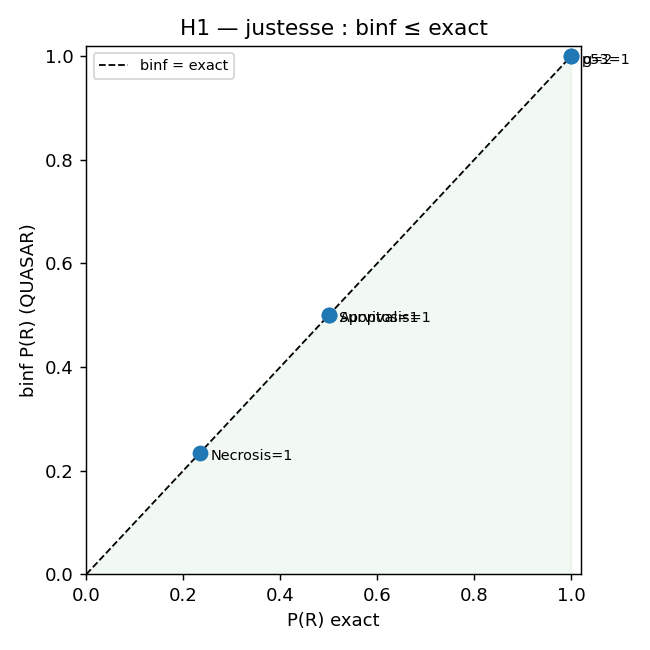

In [22]:
# ---- Figure 1 : binf vs exact (diagonale de justesse) ----
df1 = FINESSE.dropna(subset=["binf", "exact"]).copy()
df1.to_csv(FIG / "fig1_data.csv", index=False)
display(df1)

def _draw1():
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="binf = exact")
    ax.scatter(df1["exact"], df1["binf"], c="tab:blue", s=60, zorder=3)
    for _, r in df1.iterrows():
        ax.annotate(r["objectif"], (r["exact"], r["binf"]),
                    textcoords="offset points", xytext=(6, -4), fontsize=8)
    ax.fill_between([0, 1], [0, 1], 0, color="tab:green", alpha=0.06)
    ax.set_xlabel("P(R) exact"); ax.set_ylabel("binf P(R) (QUASAR)")
    ax.set_title("H1 — justesse : binf ≤ exact")
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout(); fig.savefig(FIG / "fig1_binf_vs_exact.png", dpi=130)

_p = FIG / "fig1_binf_vs_exact.png"
if render_figure(_draw1, _p):
    display(Image(filename=str(_p)))

,modèle,objectif,automates,binf,exact,écart relatif
0,p53-mdm2,p53=1,3,1.000000,1.000000,0.000000e+00
1,cellfate,Apoptosis=1,11,0.500000,0.500000,0.000000e+00
2,cellfate,Necrosis=1,11,0.234375,0.234375,-1.184238e-16
3,cellfate,Survival=1,11,0.500000,0.500000,0.000000e+00
4,multivalued-demo,g=2,2,1.000000,1.000000,-1.550760e-12


✅ figure écrite : /home/lfippo/Dev/quasar/experiments/figures/fig2_finesse_vs_taille.png


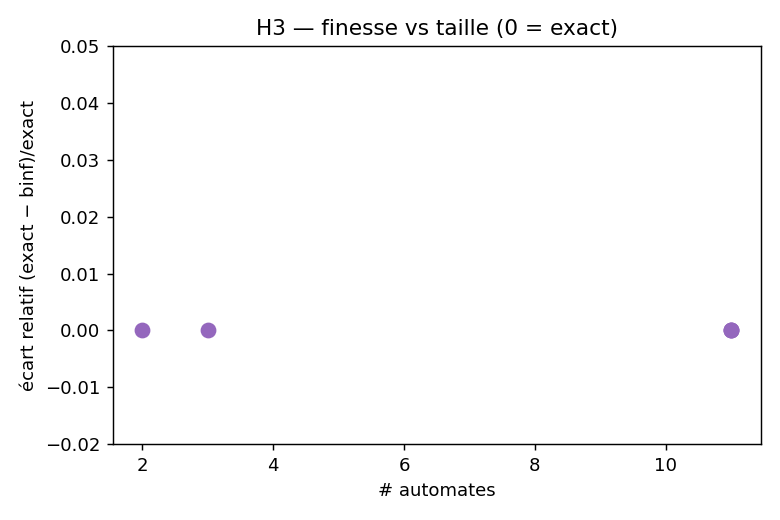

In [23]:
# ---- Figure 2 : finesse (écart relatif) vs taille ----
df2 = FINESSE.dropna(subset=["écart relatif", "automates"]).copy()
df2.to_csv(FIG / "fig2_data.csv", index=False)
display(df2)

def _draw2():
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df2["automates"], df2["écart relatif"], c="tab:purple", s=60)
    ax.set_xlabel("# automates"); ax.set_ylabel("écart relatif (exact − binf)/exact")
    ax.set_title("H3 — finesse vs taille (0 = exact)")
    hi = max(0.05, float(df2["écart relatif"].max() or 0) * 1.2 + 0.02)
    ax.set_ylim(-0.02, hi)
    fig.tight_layout(); fig.savefig(FIG / "fig2_finesse_vs_taille.png", dpi=130)

_p = FIG / "fig2_finesse_vs_taille.png"
if render_figure(_draw2, _p):
    display(Image(filename=str(_p)))

,modèle,objectif,automates,t_QUASAR (s)
4,multivalued-demo,g=2,2,0.637
0,p53-mdm2,p53=1,3,0.525
1,cellfate,Apoptosis=1,11,0.600
2,cellfate,Necrosis=1,11,0.564
3,cellfate,Survival=1,11,0.603


✅ figure écrite : /home/lfippo/Dev/quasar/experiments/figures/fig3_scalabilite.png


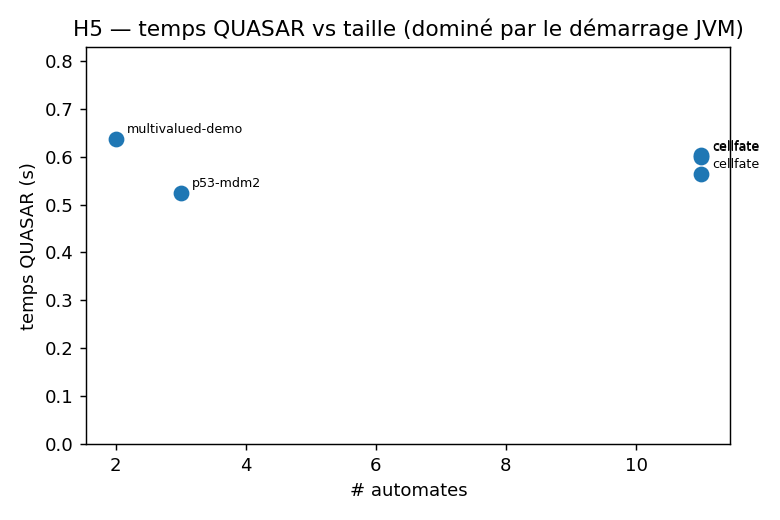

In [24]:
# ---- Figure 3 : scalabilité (temps QUASAR vs taille) ----
df3 = SCALABILITY.copy()
df3.to_csv(FIG / "fig3_data.csv", index=False)
display(df3)

def _draw3():
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 4))
    # nuage de points (plusieurs objectifs partagent une même taille) — pas de
    # ligne trompeuse ; sur ces petits modèles le temps est dominé par le
    # démarrage JVM (~0.5 s), d'où l'absence de tendance d'échelle exploitable.
    ax.scatter(df3["automates"], df3["t_QUASAR (s)"], c="tab:blue", s=60, zorder=3)
    for _, r in df3.iterrows():
        ax.annotate(r["modèle"], (r["automates"], r["t_QUASAR (s)"]),
                    textcoords="offset points", xytext=(6, 3), fontsize=7)
    ax.set_xlabel("# automates"); ax.set_ylabel("temps QUASAR (s)")
    ax.set_ylim(0, max(0.1, float(df3["t_QUASAR (s)"].max()) * 1.3))
    ax.set_title("H5 — temps QUASAR vs taille (dominé par le démarrage JVM)")
    fig.tight_layout(); fig.savefig(FIG / "fig3_scalabilite.png", dpi=130)

_p = FIG / "fig3_scalabilite.png"
if render_figure(_draw3, _p):
    display(Image(filename=str(_p)))

,budget,lower,upper,exact?
0,1,0.25000,0.750,False
1,2,0.31250,0.625,False
2,4,0.40625,0.500,False
3,8,0.50000,0.500,True
4,16,0.50000,0.500,True
5,32,0.50000,0.500,True
6,64,0.50000,0.500,True
7,128,0.50000,0.500,True
8,256,0.50000,0.500,True


✅ figure écrite : /home/lfippo/Dev/quasar/experiments/figures/fig4_convergence_anytime.png


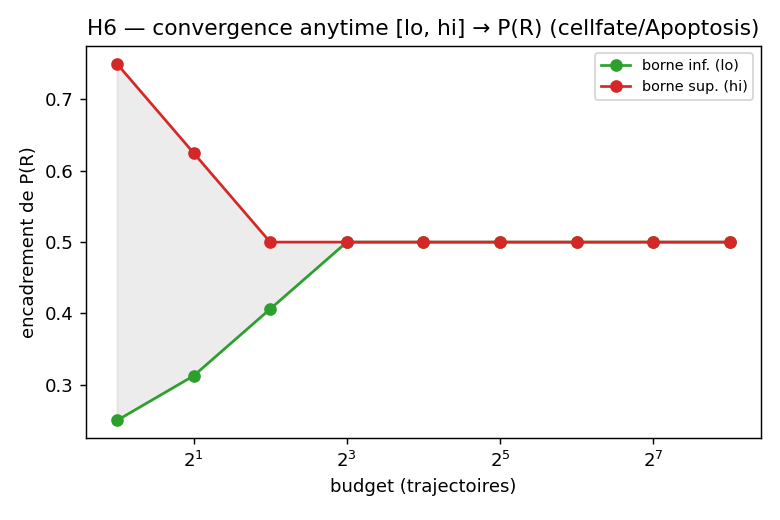

In [25]:
# ---- Figure 4 : convergence anytime (encadrement CEGAR) ----
df4 = CONVERGENCE.dropna(subset=["lower", "upper"]).copy()
df4.to_csv(FIG / "fig4_data.csv", index=False)
display(df4)

def _draw4():
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df4["budget"], df4["lower"], "o-", color="tab:green", label="borne inf. (lo)")
    ax.plot(df4["budget"], df4["upper"], "o-", color="tab:red", label="borne sup. (hi)")
    ax.fill_between(df4["budget"], df4["lower"], df4["upper"], color="grey", alpha=0.15)
    ax.set_xscale("log", base=2)
    ax.set_xlabel("budget (trajectoires)"); ax.set_ylabel("encadrement de P(R)")
    ax.set_title("H6 — convergence anytime [lo, hi] → P(R) (cellfate/Apoptosis)")
    ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FIG / "fig4_convergence_anytime.png", dpi=130)

_p = FIG / "fig4_convergence_anytime.png"
if render_figure(_draw4, _p):
    display(Image(filename=str(_p)))

In [26]:
# ---- Tableau de synthèse H1–H6 ----
def _status_h5():
    return "PARTIEL — modèles disponibles seulement (grands modèles non acquis)"

SYNTHESE = pd.DataFrame([
    {"hypothèse": "H1 — justesse (proba)",   "statut": "VALIDÉ (oracle interne + MDD)" + ("" if (ORACLES["storm"] or ORACLES["maboss"]) else " ; externes SKIPPED")},
    {"hypothèse": "H2 — justesse (délai)",   "statut": ("VALIDÉ — T(R) vs quantiles MaBoSS (V1)" if ORACLES["maboss"] else "PRÊT (V1 livré) — SKIPPED : MaBoSS absent")},
    {"hypothèse": "H3 — finesse",            "statut": "VALIDÉ (écart nul : P exacte sur ces modèles)"},
    {"hypothèse": "H4 — scénarios critiques","statut": ("VALIDÉ — recouvrement Jaccard (V1)" if ORACLES["maboss"] else "PRÊT (V1 livré) — SKIPPED : MaBoSS absent")},
    {"hypothèse": "H5 — scalabilité",        "statut": _status_h5()},
    {"hypothèse": "H6 — apport optimisations","statut": "PARTIEL — anytime VALIDÉ ; semi-anneau/ZDD BLOQUÉS (A2/A3)"},
])
SYNTHESE

,hypothèse,statut
0,H1 — justesse (proba),VALIDÉ (oracle interne + MDD) ; externes SKIPPED
1,H2 — justesse (délai),PRÊT (V1 livré) — SKIPPED : MaBoSS absent
2,H3 — finesse,VALIDÉ (écart nul : P exacte sur ces modèles)
3,H4 — scénarios critiques,PRÊT (V1 livré) — SKIPPED : MaBoSS absent
4,H5 — scalabilité,PARTIEL — modèles disponibles seulement (grands modèles ...
5,H6 — apport optimisations,PARTIEL — anytime VALIDÉ ; semi-anneau/ZDD BLOQUÉS (A2/A3)


In [27]:
# ---- Run-bundle reproductible (DoD §8.4) ----
# Dépôt local dans experiments/.quasar-repo ; ajout d'un modèle ; export du bundle.
# Idempotent : si l'id existe déjà, on passe directement au bundle.
bundle_path = EXP / "validation_chap4.bundle"
run_quasar(["repo", "init"], want_json=False, cwd=str(EXP), use_cache=False)
run_quasar(["repo", "add", str(MODELS["cellfate"]["anx"]),
            "--id", "cellfate-validation",
            "--tags", "chap4", "--tags", "validation"],
           want_json=False, cwd=str(EXP), use_cache=False)
bnd = run_quasar(["repo", "bundle", "cellfate-validation", "-o", str(bundle_path)],
                 want_json=False, cwd=str(EXP), use_cache=False)
if bnd["_ok"] and bundle_path.is_file():
    print("✅ run-bundle écrit :", bundle_path, f"({bundle_path.stat().st_size} o)")
else:
    print("⚠️ BLOQUÉ — bundle non produit :", bnd["_raw"][:120])
print("\nFigures :", *(p.name for p in sorted(FIG.glob('*.png'))))

✅ run-bundle écrit : /home/lfippo/Dev/quasar/experiments/validation_chap4.bundle (1421 o)

Figures : fig1_binf_vs_exact.png fig2_finesse_vs_taille.png fig3_scalabilite.png fig4_convergence_anytime.png


---

### Conclusion

- **H1 (justesse)** est testée comme une **assertion exécutable** qui échoue
  bruyamment : c'est le cœur méthodologique. Validée ici contre l'oracle exact
  interne de QUASAR (BFS du cône + MDD) ; les oracles externes MaBoSS/Storm
  s'ajoutent automatiquement s'ils sont installés.
- **H3** est triviale sur ces petits modèles car QUASAR calcule `P(R)`
  *exactement* (CTMC/MDD) ; l'écart n'apparaît qu'au-delà du plafond d'états.
- **H6 (anytime)** est démontrée réellement (encadrement CEGAR monotone).
- **H2, H4, H5 (grands modèles), H6 (semi-anneau/ZDD)** sont **bloqués** par des
  capacités absentes — listées en Section 7 sans aucun résultat fabriqué.

Le détail des prérequis et des modules à arbitrer est dans `experiments/README.md`.